**Informations available**

| **Category**         | **Details**                                                                                     |
|-----------------------|-------------------------------------------------------------------------------------------------|
| **Data size** | 3 files : `data` (captors data by time), `sensors` (captors metadata), `covariates` |
| **Number of records for data** | 20 millions                                                                                     |
| **Covered period**   | 2018-01-01 → 2024-12-31 (7 ans)                                                                 |
| **Sensors**           | 60 000 capteurs (dont 93 pour l'ozone)                                                     |
| **Filtered records** | 3 millions (seulement 51 capteurs retenus, car certains arrêtés avant 2018)                                                 |
| **Tri des valeurs pour ne garder que les max : Variable `maxOzone`** | → 126 000 enregistrements                                     |
| **Covariables**           | Température max/min, pluie, vitesse du vent, humidité, pression atmosphérique, rayonnement solaire, etc.         |    


In [1]:
import pandas as pd
data = pd.read_csv("weekly_ozone_and_covariates.csv")
stations = pd.read_csv("stations_infos.csv")

**Plots**

Let's plot a map of the sensors to see where they are located.

In [3]:
import plotly.express as px


fig = px.scatter_geo(
    stations,
    lat='lat',
    lon='lng',
    text='idSensore',
    scope='europe',
    projection='natural earth'
)
fig.update_layout(title="Localisation des stations de mesure d'Ozone")
fig.show()


ValueError: Value of 'text' is not the name of a column in 'data_frame'. Expected one of ['45.54852147', '8.84732669', 'Unnamed: 2', 'Unnamed: 3', '2018-01-01', '2025-01-01'] but received: idSensore

The sensors are located in the North of Italy, mainly in the Lombardy region.

We then plot the maxOzone level for a random station to see the seasonal trend.

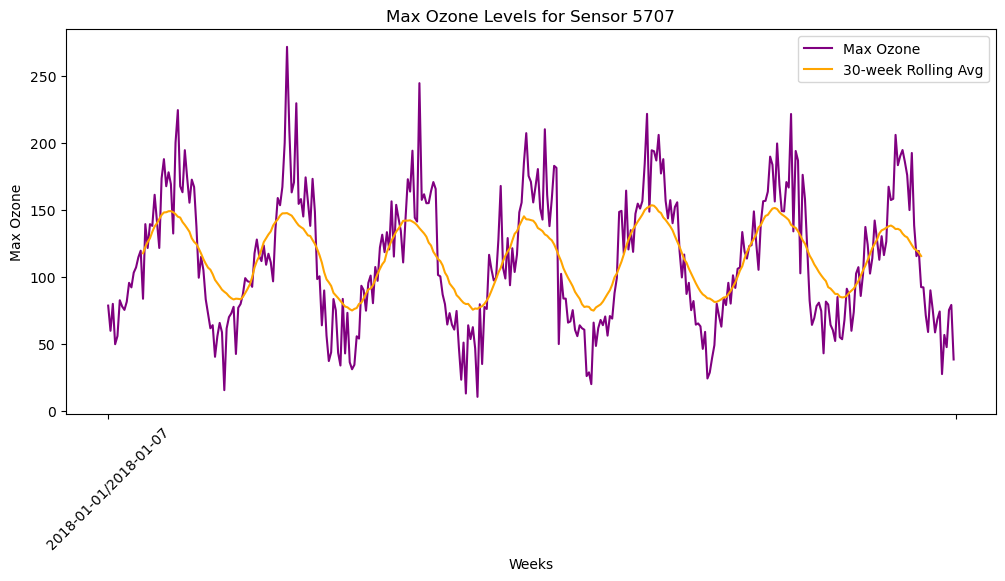

In [11]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


daily_avg = data["maxOzone"][data["idSensor"] == 5707].rolling(window=30, center=True).mean()

fig, ax = plt.subplots(figsize=(12,5))
plt.plot(data["week"][data["idSensor"] == 5707], 
         data["maxOzone"][data["idSensor"] == 5707], color='purple', label='Max Ozone')
plt.plot(data["week"][data["idSensor"] == 5707], daily_avg, color='orange', label='30-week Rolling Avg')
#plt.plot(data["maxOzone"][pd.to_datetime(data["day"]) < pd.to_datetime("2019")][data["idSensor"] == 5707], 
#         color='red', linestyle='--', label='Pre-2019 Data')
plt.title("Max Ozone Levels for Sensor 5707")
plt.xlabel("Weeks")
plt.ylabel("Max Ozone")
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [13]:
data_trend = data[data["idSensor"] == 5707]["maxOzone"].values[:-52] - data[data["idSensor"] == 5707]["maxOzone"].values[52:]

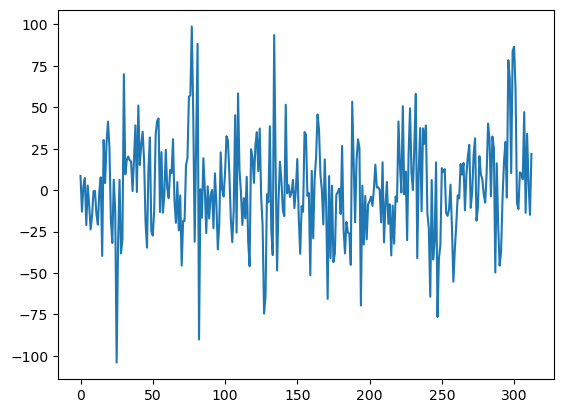

In [15]:
plt.plot(data_trend)
plt.show()

In [29]:
data[data["idSensor"] == 5707]["maxOzone"].values[:-365]

array([15.8, 71.2, 68.6, ..., 28.9, 10.3,  7.3])

Well maybe we should plot a mean of all the stations to see a more general trend.

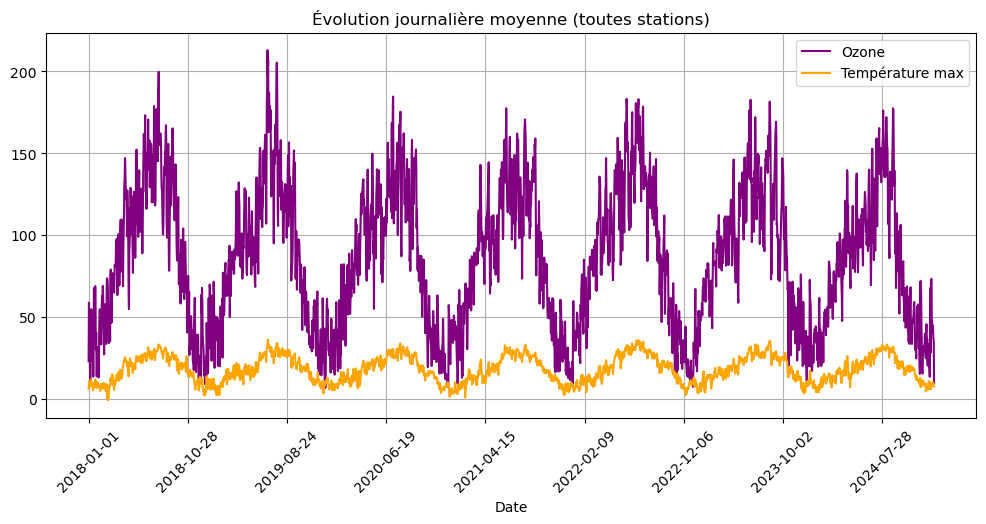

In [16]:
daily_avg = data.groupby('day', as_index=False).mean(numeric_only=True)
fig, ax = plt.subplots(figsize=(12,5))
plt.plot(daily_avg['day'], daily_avg['maxOzone'], label='Ozone', color='purple')
plt.plot(daily_avg['day'], daily_avg['maxTemp'], label='Température max', color='orange')
plt.legend()
plt.title("Évolution journalière moyenne (toutes stations)")
plt.xlabel("Date")
ax.xaxis.set_major_locator(plt.MaxNLocator(10))  # max 10 dates visibles
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


<Figure size 1200x600 with 0 Axes>

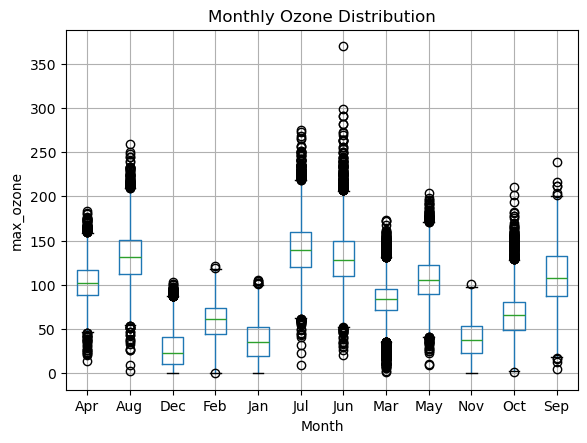

In [17]:

data['day'] = pd.to_datetime(data['day'], errors='coerce')

df_plot = pd.DataFrame({"month" : data["day"].dt.strftime("%b") ,
                        "month_num": data["day"].dt.month, 
                        "max_ozone": data["maxOzone"]})

     

df_plot = df_plot.sort_values("month_num")

# Create boxplot
plt.figure(figsize=(12,6))
df_plot.boxplot(column="max_ozone", by="month")
plt.title("Monthly Ozone Distribution")
plt.suptitle("")  # Remove automatic title
plt.xlabel("Month")
plt.ylabel("max_ozone")
plt.show()


At this point we explore the relation between the covariates and the maxOzone level.

Starting with the maxTemperature

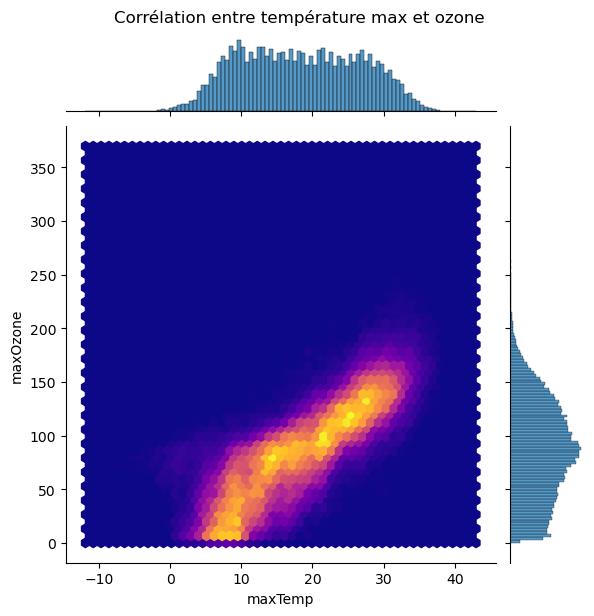

In [23]:
import seaborn as sns
sns.jointplot(data=data, x='maxTemp', y='maxOzone', kind='hex', cmap='plasma')
plt.suptitle("Corrélation entre température max et ozone", y=1.02)
plt.show()


The color of the points reflects the number of observations in that area (lighter = more observations). There is also a bar showing the density of points along each axis.

We can see that there is a positive correlation between the maxTemperature and the maxOzone level.

We now look at the rainfall.

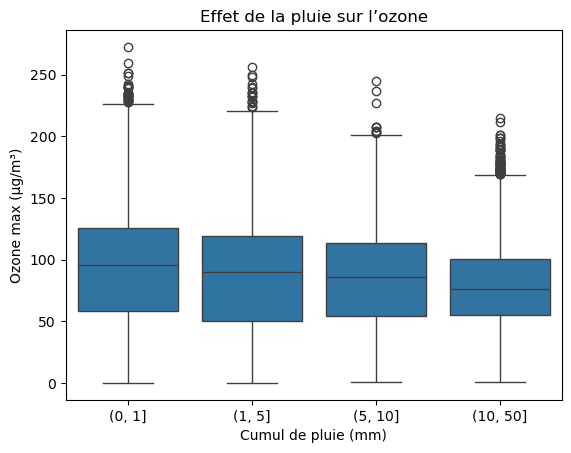

In [27]:
sns.boxplot(data=data, x=pd.cut(data['rainSum'], bins=[0,1,5,10,50]), y='maxOzone')
plt.title("Effet de la pluie sur l’ozone")
plt.xlabel("Cumul de pluie (mm)")
plt.ylabel("Ozone max (µg/m³)")
plt.show()


And we see that even there is a little correlation between the two variables, it is not as strong as the previous one.
Indeed, the max ozone level tends to be lower when there is more rainfall, but the effect is not very pronounced. We also notice that the standard deviation of the maxOzone level is higher when there is less rainfall.
Cause when it rains, the ozone is washed out of the atmosphere, so there is less ozone in the air?

Now we move to the wind speed.

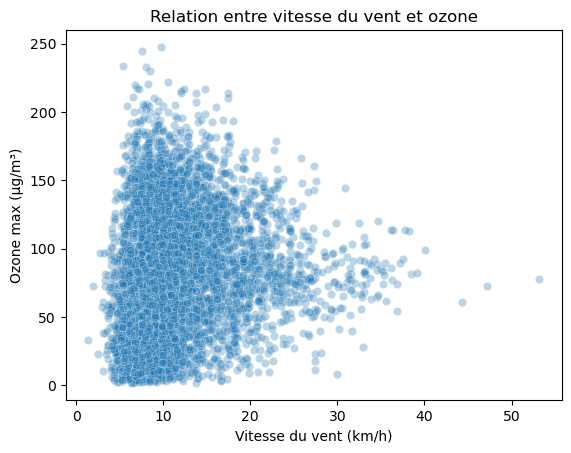

In [31]:
sns.scatterplot(data=data.sample(5000), x='windSpeed', y='maxOzone', alpha=0.3)
plt.title("Relation entre vitesse du vent et ozone")
plt.xlabel("Vitesse du vent (km/h)")
plt.ylabel("Ozone max (µg/m³)")
plt.show()


The correlation is not very strong, but it tends to be that the values are lower when the wind speed is low.
Because the wind helps to disperse the ozone, so when there is more wind, the ozone levels tend to be lower?

Then we look at other correlation plots between the covariates and the maxOzone level. First the Pearson correlation matrix, then the Spearman correlation matrix.

Text(0.5, 1.0, 'Correlation matrix')

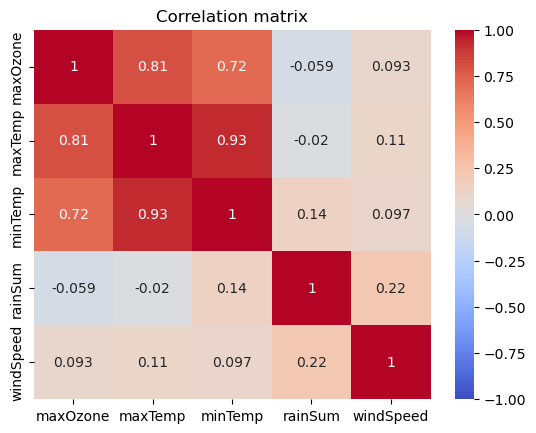

In [39]:
pearson_corr = data[['maxOzone', 'maxTemp', 'minTemp', 'rainSum', 'windSpeed']].corr(method='pearson')
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation matrix")

In [45]:
data['idSensor'].value_counts()

idSensor
6884     2554
5749     2553
6904     2551
9925     2550
20041    2549
10041    2548
6582     2547
5952     2547
17295    2544
5750     2544
6665     2542
9991     2542
10171    2540
10081    2540
12020    2540
5742     2537
10025    2536
10282    2536
10288    2536
6691     2535
10454    2533
9882     2532
10437    2532
5725     2531
6818     2531
17297    2528
5960     2528
5738     2528
5739     2524
10463    2522
5721     2521
6832     2520
5732     2519
5717     2515
9899     2510
9972     2509
6804     2508
10584    2502
9861     2499
30165    2498
9856     2494
5707     2478
9997     2474
20154    2436
5710     2417
17288    2389
5730     2376
5718     2047
5719     1991
10270    1902
5735     1517
Name: count, dtype: int64

In [83]:
data[data['idSensor'] == 17288]['day'].dt.year.value_counts()

day
2024    357
2022    353
2019    350
2023    343
2020    338
2018    335
2021    312
2025      1
Name: count, dtype: int64

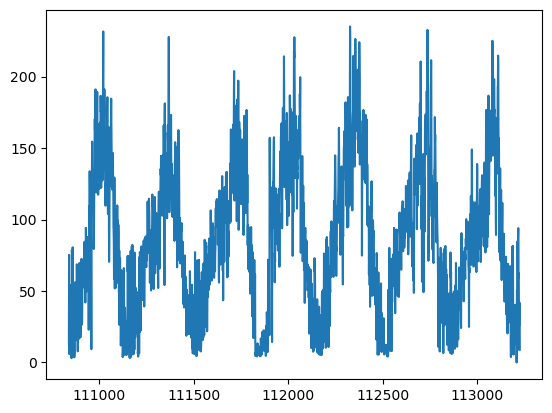

In [67]:
plt.plot(data[data['idSensor'] == 17288]['maxOz])

Text(0.5, 1.0, 'Matrice de corrélation (Spearman)')

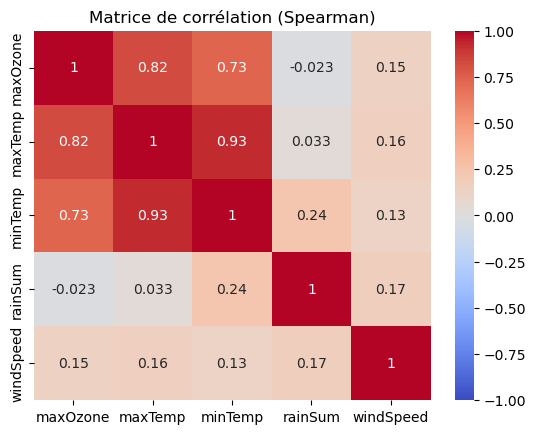

In [ ]:
spearman_corr = data[['maxOzone', 'maxTemp', 'minTemp', 'rainSum', 'windSpeed']].corr(method='spearman')
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Matrice de corrélation (Spearman)")

We now plot a scatter matrix of the variables by variance to see if there are some interesting relations between them.

<Figure size 1000x1000 with 0 Axes>

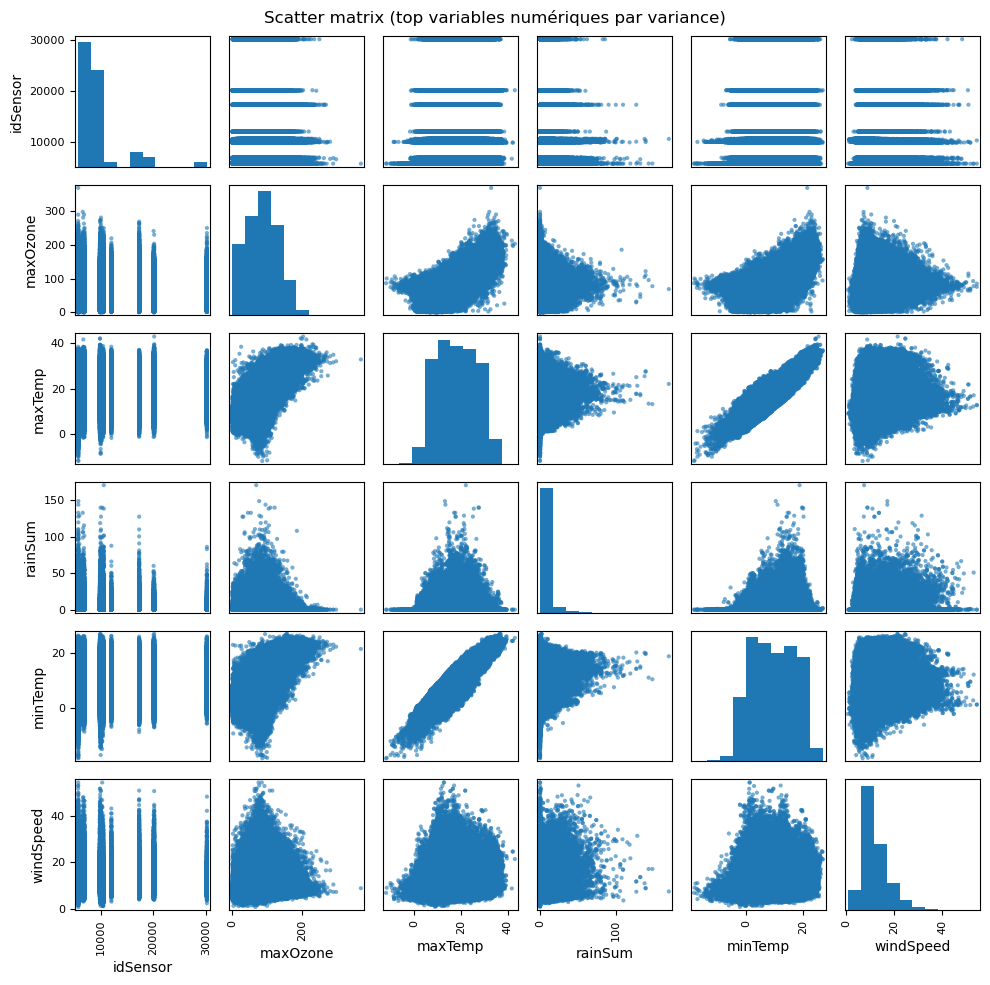

In [56]:
from pandas.plotting import scatter_matrix
import numpy as np

num_cols = data.select_dtypes(include=[np.number]).var().sort_values(ascending=False).index.tolist()
top_cols = num_cols[:8] if len(num_cols) > 8 else num_cols
if len(top_cols) >= 2:
    sm_fig = plt.figure(figsize=(10,10))
    scatter_matrix(data[top_cols].dropna(), alpha=0.6, diagonal='hist', figsize=(10,10))
    plt.suptitle("Scatter matrix (top variables numériques par variance)")
    plt.tight_layout()
    plt.show()

**Conclusion**

The covariates that seem to have the most influence on the maxOzone level are the maxTemperature, and the minTemperature as shown with the plots and the correlation matrix. We should also of course take care about the temporal aspect of the data, because there is a clear seasonal trend in the maxOzone level, as shown in the first plots.

We can see after than the frequentist approach is not relevant here because of the strong autocorrelation in the data (time series data). We will need to use a Bayesian approach to model the data and take into account the autocorrelation.

In [ ]:
import statsmodels.api as sm


top_covs = pearson_corr.abs().head(6).index.tolist()
n = len(top_covs)
regs = data[["maxOzone", "maxTemp", "minTemp", "rainSum", "windSpeed"]].dropna()
X = regs[["maxTemp", "minTemp", "rainSum", "windSpeed"]]
X = sm.add_constant(X)
y = regs["maxOzone"]
model = sm.OLS(y, X).fit()
print("\nRésumé OLS (exploratoire) — coefficient estimates :\n")
print(model.summary())


Résumé OLS (exploratoire) — coefficient estimates :

                            OLS Regression Results                            
Dep. Variable:               maxOzone   R-squared:                       0.664
Model:                            OLS   Adj. R-squared:                  0.664
Method:                 Least Squares   F-statistic:                 6.212e+04
Date:              lun., 10 nov. 2025   Prob (F-statistic):               0.00
Time:                        17:20:21   Log-Likelihood:            -5.9022e+05
No. Observations:              125782   AIC:                         1.180e+06
Df Residuals:                  125777   BIC:                         1.180e+06
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

We still can try to drop some data and keep only one year to see what happens.

In [ ]:
top_covs = pearson_corr.abs().head(6).index.tolist()
n = len(top_covs)
regs = data[["maxOzone", "maxTemp", "minTemp", "rainSum", "windSpeed"]][pd.to_datetime(data["day"]) < pd.to_datetime("2019")].dropna()
X = regs[["maxTemp", "minTemp", "rainSum", "windSpeed"]]
X = sm.add_constant(X)
y = regs["maxOzone"]
model = sm.OLS(y, X).fit()
print("\nRésumé OLS (exploratoire) — coefficient estimates :\n")
print(model.summary())


Résumé OLS (exploratoire) — coefficient estimates :

                            OLS Regression Results                            
Dep. Variable:               maxOzone   R-squared:                       0.689
Model:                            OLS   Adj. R-squared:                  0.689
Method:                 Least Squares   F-statistic:                 1.012e+04
Date:              lun., 10 nov. 2025   Prob (F-statistic):               0.00
Time:                        17:44:38   Log-Likelihood:                -86176.
No. Observations:               18249   AIC:                         1.724e+05
Df Residuals:                   18244   BIC:                         1.724e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

Conclusion : even if we drop data and keep only one year, the autocorrelation is still very strong (Durbin-Watson ~ 0.54). The coefficients of the regression also change significantly, indicating that the effects of the covariates on the maxOzone level are dependent on the year selected. Therefore, it is not sufficient to simply reduce the dataset to a single year to address the autocorrelation issue

| Indicator           | 7 years                                                                  | 1 year                                                                 | Interpretation                                                                                                                                              |
| -------------------- | ---------------------------------------------------------------------- | -------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **R²**               | 0.664                                                                  | 0.689                                                                | Slight increase: more variance explained. Perhaps because a single year reduces overall trends and makes relationships more "linear".  |
| **No. Observations** | 125 782                                                                | 18 249                                                               | Less data → less statistical power, but enough to estimate correctly.                                                                    |
| **Durbin-Watson**    | 0.546                                                                  | 0.541                                                                | Almost identical: autocorrelation still very strong! → keeping only one year **does not solve daily autocorrelation**.                          |
| **Coefficients**     | maxTemp = 5.69, minTemp = -1.55, rainSum = -0.0127, windSpeed = 0.0405 | maxTemp = 5.46, minTemp = -0.96, rainSum = 0.116, windSpeed = -0.176 | Signs and magnitudes change slightly, some variables change direction (rainSum and windSpeed) → effects dependent on the selected year. |


Ok, let's move to a Bayesian approach to model the data.

In [ ]:
# Script de ChattyGPT, ne pas run ça sert à rien je sais pas ce que ça fait et en plus même au bout de 20min il mouline encore...
"""
Bayesian linear regression for maxOzone with covariates.
Usage:
  conda create -n ozone_env -c conda-forge python=3.10 pymc arviz matplotlib pandas
  conda activate ozone_env
  python run_bayesian_ozone.py
"""
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
from pathlib import Path

# === Parameters ===
DATA_PATH = "daily_ozone_and_covariates.csv"   # place this script in the same folder as your CSV, or give full path
OUT_TRACE = "ozone_pymc_trace.nc"
SUBSAMPLE = None   # set to an integer (e.g., 5000) for quick debugging; set to None to use all data
N_CHAINS = 4
N_DRAWS = 1000
N_TUNE = 1000
TARGET_ACCEPT = 0.9

# === Load data ===
data = pd.read_csv(DATA_PATH)
# detect ozone column (explicitly from EDA)
ozone_col = "maxOzone"
# covariates to use (remove idSensor)
covs = [c for c in ["maxTemp","minTemp","rainSum","windSpeed"] if c in data.columns]

data_model = data[[ozone_col] + covs].dropna().copy()
if SUBSAMPLE is not None and SUBSAMPLE < len(data_model):
    data_model = data_model.sample(n=SUBSAMPLE, random_state=42)

y = data_model[ozone_col].values
X = data_model[covs].values
# standardize covariates for better priors/sampling
X_mean = X.mean(axis=0)
X_std = X.std(axis=0, ddof=0)
X_std[X_std == 0] = 1.0
Xz = (X - X_mean) / X_std

print(f"Observations: {len(y)}; covariates: {covs}")

# === Model ===
with pm.Model() as model:
    # priors (on standardized covariates)
    intercept = pm.Normal("Intercept", mu=0.0, sigma=10.0)
    betas = pm.Normal("betas", mu=0.0, sigma=1.0, shape=len(covs))  # weakly-informative
    sigma = pm.HalfNormal("sigma", sigma=5.0)

    mu = intercept + pm.math.dot(Xz, betas)
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)

    # choose sampling strategy:
    # - for final runs on full dataset, use NUTS (may be slow but accurate)
    # - for quick runs on large datasets, consider pm.fit (ADVI) as an approx
    print("Starting NUTS sampling ...")
    trace = pm.sample(draws=N_DRAWS, tune=N_TUNE, chains=N_CHAINS,
                      target_accept=TARGET_ACCEPT, return_inferencedata=True)

# === Save ===
az.to_netcdf(trace, OUT_TRACE)
print("Trace saved to", OUT_TRACE)

# === Summaries & plots ===
print("\nPosterior summary (Intercept, betas, sigma):")
print(az.summary(trace, var_names=["Intercept", "betas", "sigma"], round_to=3))

az.plot_trace(trace, var_names=["Intercept", "betas", "sigma"])
plt.tight_layout()
plt.show()

az.plot_forest(trace, var_names=["betas"], combined=True)
plt.title("Coefficients (posteriors)")
plt.show()

# Posterior predictive check
with model:
    ppc = pm.sample_posterior_predictive(trace, var_names=["y_obs"], random_seed=42)
y_ppc = ppc["y_obs"]
plt.figure(figsize=(8,4))
plt.hist(y, bins=50, alpha=0.5, label="observed")
plt.hist(y_ppc.mean(axis=0), bins=50, alpha=0.5, label="ppc mean")
plt.legend()
plt.title("Observed vs PPC mean (histograms)")
plt.show()

# Helpful note to translate betas back to original scale:
print("\nNOTE: betas are on standardized covariates. To obtain effect on original scale:")
for name, sd in zip(covs, X_std):
    print(f"  beta_{name}_on_original_scale ≈ posterior_beta / {sd:.4g}")


WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


Observations: 125782; covariates: ['maxTemp', 'minTemp', 'rainSum', 'windSpeed']
Starting NUTS sampling ...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, betas, sigma]


Output()

**Choices de priors & justification (by Chatty)**

Intercept ~ Normal(0, 10) : large, couvre une large gamme pour maxOzone centrée si covariables standardisées.

betas ~ Normal(0,1) : prior faible mais informatif sur l’échelle standardisée (couvre effets modestes ; si tu veux plus serré, réduire sigma).

sigma ~ HalfNormal(5) : dispersion résiduelle positive ; 5 est large par sécurité.

Raison : standardiser covariables rend ces priors plus interprétables et stables pour NUTS.

**Interprétation des coefficients**

Les betas sont estimés sur covariables standardisées. Donc :

Un beta_j correspond à la variation moyenne de maxOzone (en unités de la variable réponse) pour un écart-type d’augmentation de la covariable j.

Pour revenir à l’échelle d’origine (par unité de la covariable), divise beta_j par sd(X_j) (voir le script, il affiche la transformation).

Rappelle-toi d’examiner : intervalles crédibles (94% ou 95%), R̂ (should be ≈1), effective sample size (ESS).